In [1]:
import numpy as np
import xarray as xr

xr.set_options(keep_attrs=True)
import pandas as pd
from easygems.healpix import healpix as hp
import intake

# Plots
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import cmocean as cmo
import seaborn as sns
import cartopy.crs as ccrs
import easygems.healpix as egh

###
# Warnings
import warnings

warnings.filterwarnings(action="ignore")

# Accessing data 

## Catalogs from DKRZ

One way to access climate data is by using catalog provided by DKRZ, e.g., km-scale global hackathon:

In [2]:
cat = intake.open_catalog("https://data.nextgems-h2020.eu/online.yaml")
print(list(cat))

['ICON', 'ERA5', 'JRA3Q', 'MERRA2', 'IFS', 'IMERG', 'GSMaP', 'tutorial']


Each entry represent a small data set per simulation of the km-scale global hackathon.

For example, [ERA5](https://www.ecmwf.int/en/forecasts/dataset/ecmwf-reanalysis-v5) is a well stablished re-analysis climate dataset from ECMWF. In our catalog, the dataset has the following structure:

In [3]:
pd.DataFrame(cat["ERA5"].describe()["user_parameters"])

,name,description,type,allowed,default
0,zoom,zoom resolution of the dataset,int,"[8, 7, 6, 5, 4, 3, 2, 1, 0]",7


The dataset has a [healpix](https://easy.gems.dkrz.de/Processing/healpix/healpix_starter.html) grid structure going from a zoom 0 to 8, but what does zoom level mean?

[Healpix grid](https://healpix.sourceforge.io/) is a grid specifically designed for sphere with equal area between cells in a hierarchical structure. There are different ways to characterize it:

- $\mathrm{N_{cells}}$: Number of cells or pixels, which is a multiple of 12. The minimum amount of cells is 12 and every time we refine the grid, we divide the cell in four.
- nside: is the parameter that defines the resolution of the pixelation, $\mathrm{N_{cells}}=12 \times \mathrm{nside}^2$
- z: refers to the nesting depth $\mathrm{nside} = 4^\mathrm{z}$ 

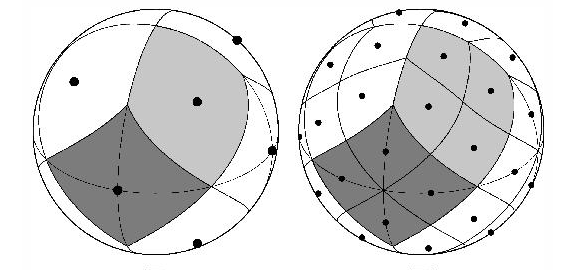

So let's compare two dataset with different zoom level, 0 and 6.

In [4]:
print_basic_info_dataset = lambda ds, var: print(
    f"From {str(ds.time.values[0])[:10]} to {str(ds.time.values[-1])[:10]} | ncells {ds.cell.size: .2e} |  nside {hp.npix2nside(ds.cell.size)} | "
    + f"nbytes {ds['2t'].nbytes * 1e-6: .2f} MBs"
    if var is None
    else f"nbytes {ds[var].nbytes * 1e-6: .2f} MBs"
)

In [5]:
ds_era5_zoom_0 = cat["ERA5"](zoom=0).to_dask()
ds_era5_zoom_3 = cat["ERA5"](zoom=3).to_dask()
ds_era5_zoom_6 = cat["ERA5"](zoom=6).to_dask()

In [6]:
print_basic_info_dataset(ds_era5_zoom_0, None), print_basic_info_dataset(
    ds_era5_zoom_3, None
), print_basic_info_dataset(ds_era5_zoom_6, None);

From 1940-01-01 to 2023-12-01 | ncells  1.20e+01 |  nside 1 | nbytes  0.05 MBs
From 1940-01-01 to 2023-12-01 | ncells  7.68e+02 |  nside 8 | nbytes  3.10 MBs
From 1940-01-01 to 2023-12-01 | ncells  4.92e+04 |  nside 64 | nbytes  198.18 MBs


Since we are openning with xarray, we can check the dataset structure just by calling the variable.

We have dimensions, coordinates, and data variables. Each variable from each list has attributes in a data structure of a dictionary.

In [7]:
ds_era5_zoom_0

<xarray.Dataset> Size: 33MB
Dimensions:  (time: 1008, cell: 12, level: 37)
Coordinates:
  * cell     (cell) float32 48B 0.0 1.0 2.0 3.0 4.0 ... 7.0 8.0 9.0 10.0 11.0
    crs      float32 4B ...
    lat      (cell) float32 48B dask.array<chunksize=(12,), meta=np.ndarray>
  * level    (level) float32 148B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
    lon      (cell) float32 48B dask.array<chunksize=(12,), meta=np.ndarray>
  * time     (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2023-12-01
Data variables: (12/111)
    100u     (time, cell) float32 48kB dask.array<chunksize=(1008, 12), meta=np.ndarray>
    100v     (time, cell) float32 48kB dask.array<chunksize=(1008, 12), meta=np.ndarray>
    10fg     (time, cell) float32 48kB dask.array<chunksize=(1008, 12), meta=np.ndarray>
    10si     (time, cell) float32 48kB dask.array<chunksize=(1008, 12), meta=np.ndarray>
    10u      (time, cell) float32 48kB dask.array<chunksize=(1008, 12), meta=np.ndarray>
    10v      (time, cell) float32 48kB dask.array<chunksize=(1008, 12), meta=np.ndarray>
    ...       ...
    uvb      (time, cell) float32 48kB dask.array<chunksize=(1008, 12), meta=np.ndarray>
    v        (time, level, cell) float32 2MB dask.array<chunksize=(1008, 4, 12), meta=np.ndarray>
    vo       (time, level, cell) float32 2MB dask.array<chunksize=(1008, 4, 12), meta=np.ndarray>
    w        (time, level, cell) float32 2MB dask.array<chunksize=(1008, 4, 12), meta=np.ndarray>
    z        (time, level, cell) float32 2MB dask.array<chunksize=(1008, 4, 12), meta=np.ndarray>
    zust     (time, cell) float32 48kB dask.array<chunksize=(1008, 12), meta=np.ndarray>
Attributes:
    acknowledgment:  Contains modified Copernicus Climate Change Service info...
    contact:         lukas.kluft@mpimet.mpg.de
    creator:         Lukas Kluft
    description:     HEALPixelation of ERA5
    source:          Post-processed dataset based on the ERA5 mirror located ...

In [8]:
print(ds_era5_zoom_0["2t"].attrs)

{'grid_mapping': 'crs', 'levtype': 'surface', 'long_name': '2 metre temperature', 'standard_name': '', 'units': 'K'}


## Netcdf Files

Another way to access data is through [netCDF files](https://www.unidata.ucar.edu/software/netcdf), which can be opened directly with xarray. The netCDF files has metadata of variables and can be usually be splitted to not have large files.

In [9]:
ds_era5_2020_lonlat = xr.open_dataset(
    "era5_t2m_2020_monthly_mean_lonlat.nc", chunks={"time": 1}
)
ds_era5_2020_z8 = xr.open_dataset(
    "era5_t2m_2020_monthly_mean_z8.nc", chunks={"time": 1}
)

On one hand, the dataset `ds_era5_2020_z8` has a [healpix](https://easy.gems.dkrz.de/Processing/healpix/healpix_starter.html) grid structure going with zoom 8, which we can check by the variable `crs`

But we can also check by using what we learnerd before hand:

In [10]:
print(ds_era5_2020_z8.crs.attrs), print_basic_info_dataset(ds_era5_2020_z8, "T2M");

{'grid_mapping_name': 'healpix', 'healpix_nside': np.int32(256), 'healpix_order': 'nested'}
nbytes  37.75 MBs


However, there are other types of grids. For example, rectangular grid with orthogonal axis latitude and longitude with, ideally, equal grid spacing. Thus, it has two dimensions, `lon` (x) and `lat` (y).

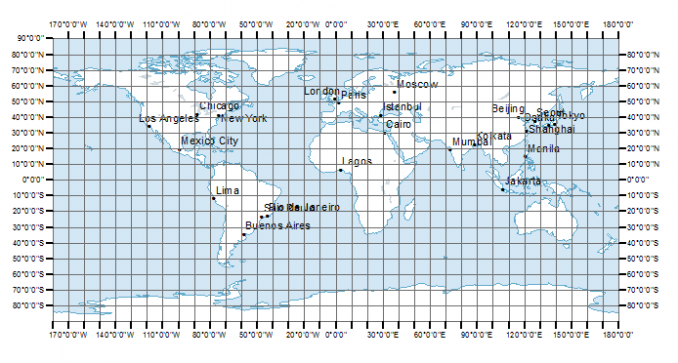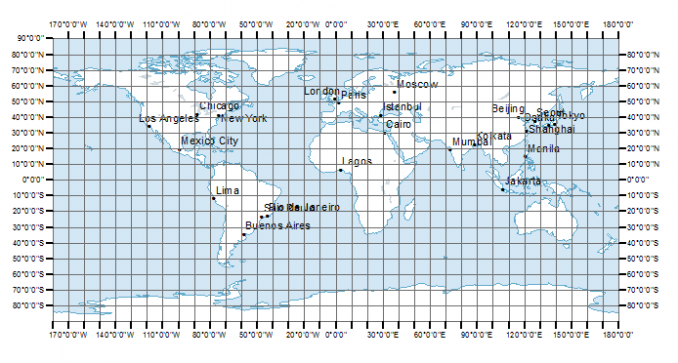

Note: Since a rectangular grid represent a sphere, the area of a grid box is different according to the latitude.
Note: There are more types of grid but we will not discuss them here

In [11]:
print(list(ds_era5_2020_lonlat.dims.keys())), print(
    f"nlon: {ds_era5_2020_lonlat.lon.size} | delta_lon: {360 / ds_era5_2020_lonlat.lon.size: .2f} deg"
)
print(
    f"nlon: {ds_era5_2020_lonlat.lat.size} | delta_lat: {180 / ds_era5_2020_lonlat.lat.size: .2f} deg"
)

['time', 'lon', 'lat']
nlon: 1440 | delta_lon:  0.25 deg
nlon: 721 | delta_lat:  0.25 deg


# How to have an easy plot
The most easy way to plot with xarray is just by calling the [standard function plot](https://docs.xarray.dev/en/latest/user-guide/plotting.html) of the library

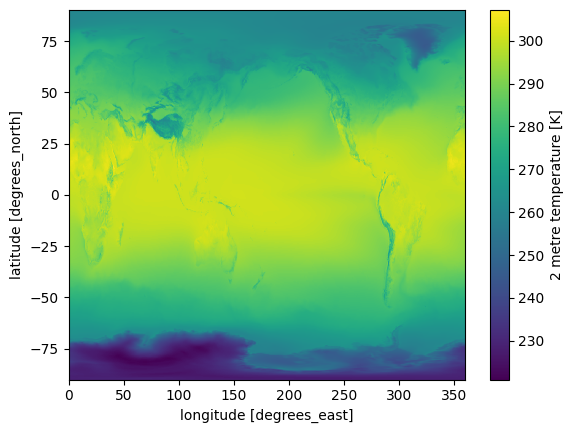

In [12]:
ds_era5_2020_lonlat.T2M.mean("time").plot()

However, for healpix grid, we have to use another library: [easygems](https://github.com/mpimet/easygems)

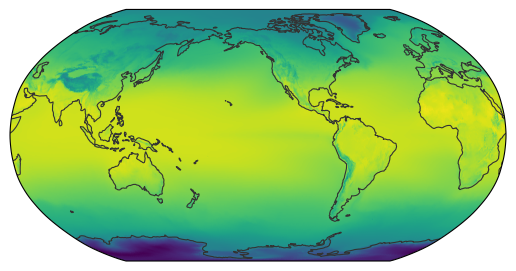

In [13]:
egh.healpix_show(ds_era5_2020_z8.T2M.mean("time"))

# Exercise

## 1 - Understanding the dataset

Use the dataset `ds_era5_zoom_0` to answer a couple of questions:

- What is the unit of near surface temperature `2t`
- What is the unit of coordinate level, what does it means?
- Find the variable for 100 meter wind speed, what is short name and units?
- Find the variable for total precipitation, what is short name and units?
- Find the variable for sea surface temperature, what is short name and units?
- Find the variable for surface short-wave (solar) radiation downwards, what is short name and units?

Now open the ICON dataset of 'ngc4008' with zoom level 0. `cat['ICON']['ngc4008'](zoom=0).to_dask()` and answer the same questions as for `ds_era5_zoom_0`

## 2 - Plot the three dataset of temperature from the catalog for the time mean between 1990 and 1994. 
For reference use [easygems documentation](https://easy.gems.dkrz.de/Processing/healpix/healpix_starter.html)

- Compute the global means for each dataset
- The three plots should be contiguous, thus, use [plt.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)
- The subplots should use a similar projection, i.e., [EqualEarth from Cartopy](https://scitools.org.uk/cartopy/docs/v0.15/crs/projections.html)

Bonus tasks:
- They should share the same colobar
- Use a proper colormap, i.e., [cmocean](https://matplotlib.org/cmocean/)

Text(0.5, 1.0, 'z=6 -> $\\overline{\\mathrm{1990-1994}}$ | T$_\\mathrm{glb} = $287.231 K')

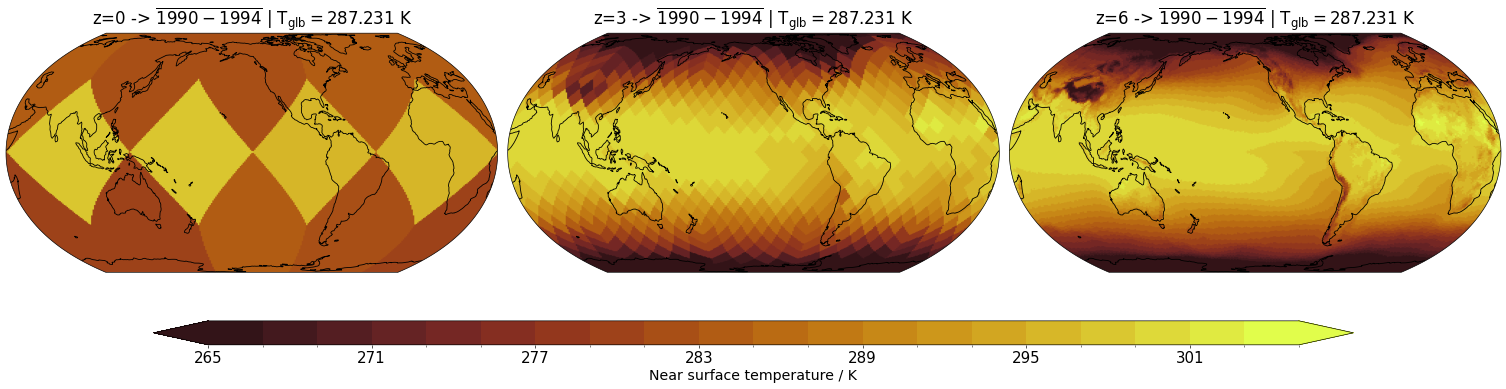

In [14]:
# Plot
cmap = cmo.cm.solar
projection = ccrs.EqualEarth(-135.58)  # ccrs.NearsidePerspective(0, 0) ccrs.Robinson()
fig, ax = plt.subplots(
    1,
    3,
    figsize=(25, 8),
    subplot_kw={"projection": projection},
    constrained_layout=True,
    facecolor="white",
    dpi=60,
)
# Colobar
bounds = np.linspace(265, 305, 21)
norm = colors.BoundaryNorm(
    boundaries=bounds, ncolors=256
)  # colors.Normalize(vmin, vmax)
im = cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(
    im,
    ax=ax.ravel().tolist(),
    cax=fig.add_axes([0.1, 0.1, 0.8, 0.05]),
    orientation="horizontal",
    extend="both",
)
cbar.ax.tick_params(labelsize=18)
cbar.set_label(label="Near surface temperature / K", size=17)
#
ax[0].set_global()
ax[0].coastlines()
ds_use = (
    ds_era5_zoom_0["2t"]
    .sel(time=slice("1990-01-01", "1994-12-31"))
    .mean("time")
    .compute()
)
egh.healpix_show(ds_use, ax=ax[0], cmap=cmap, norm=norm)
ax[0].set_title(
    r"z=0 -> $\overline{\mathrm{1990-1994}}$ | T$_\mathrm{glb} = $"
    + f"{ds_use.mean().values:.3f} K",
    fontsize=20,
)
#
ax[1].set_global()
ax[1].coastlines()
ds_use = (
    ds_era5_zoom_3["2t"]
    .sel(time=slice("1990-01-01", "1994-12-31"))
    .mean("time")
    .compute()
)
egh.healpix_show(ds_use, ax=ax[1], cmap=cmap, norm=norm)
ax[1].set_title(
    r"z=3 -> $\overline{\mathrm{1990-1994}}$ | T$_\mathrm{glb} = $"
    + f"{ds_use.mean().values:.3f} K",
    fontsize=20,
)
#
ax[2].set_global()
ax[2].coastlines()
ds_use = (
    ds_era5_zoom_6["2t"]
    .sel(time=slice("1990-01-01", "1994-12-31"))
    .mean("time")
    .compute()
)
egh.healpix_show(ds_use, ax=ax[2], cmap=cmap, norm=norm)
ax[2].set_title(
    r"z=6 -> $\overline{\mathrm{1990-1994}}$ | T$_\mathrm{glb} = $"
    + f"{ds_use.mean().values:.3f} K",
    fontsize=20,
)

## 3 - Plot the two dataset of temperature obtained from the netCDF file for the time mean 2020. 
For reference use [easygems documentation](https://easy.gems.dkrz.de/Processing/healpix/healpix_starter.html)

- Compute the global means for each dataset
- The two plots should be contiguous, thus, use [plt.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)
- The subplots should use a similar projection, i.e., [EqualEarth from Cartopy](https://scitools.org.uk/cartopy/docs/v0.15/crs/projections.html)

Bonus tasks:
- They should share the same colobar
- Use a proper colormap, i.e., [cmocean](https://matplotlib.org/cmocean/)

Text(0.5, 1.0, 'z=8 -> $\\overline{\\mathrm{2020}}$ | T$_\\mathrm{glb} = $287.954 K')

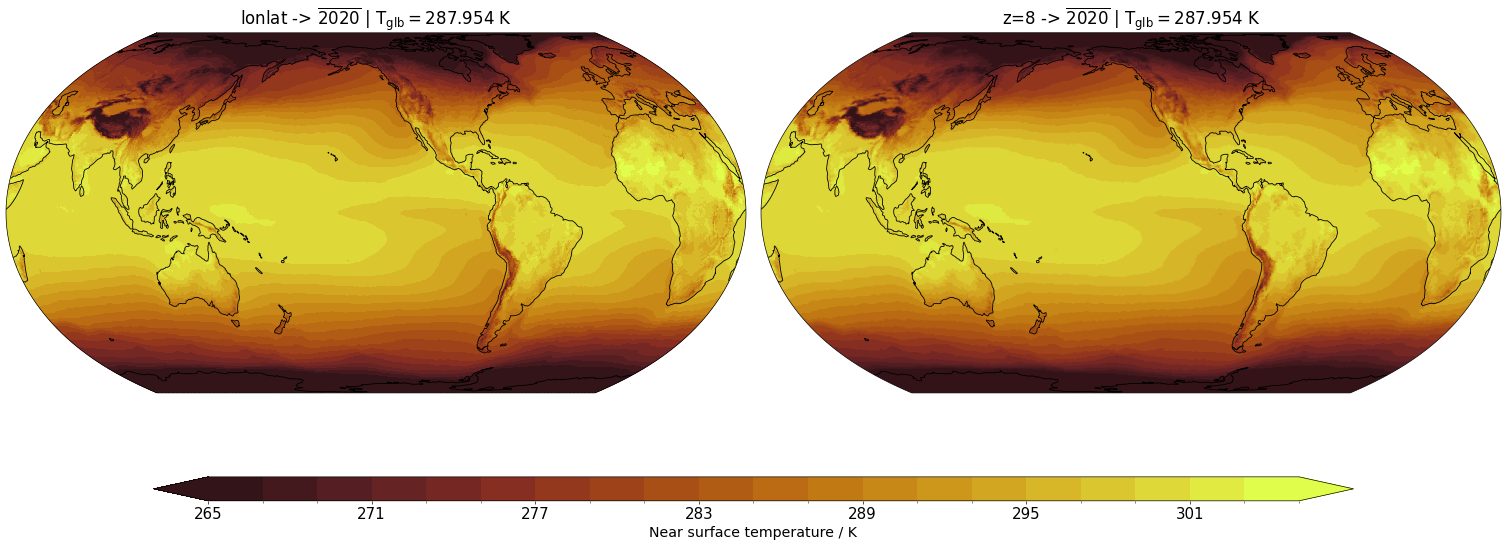

In [15]:
# Plot
cmap = cmo.cm.solar
projection = ccrs.EqualEarth(-135.58)  # ccrs.NearsidePerspective(0, 0) ccrs.Robinson()
fig, ax = plt.subplots(
    1,
    2,
    figsize=(25, 8),
    subplot_kw={"projection": projection},
    constrained_layout=True,
    facecolor="white",
    dpi=60,
)
# Colobar
bounds = np.linspace(265, 305, 21)
norm = colors.BoundaryNorm(
    boundaries=bounds, ncolors=256
)  # colors.Normalize(vmin, vmax)
im = cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(
    im,
    ax=ax.ravel().tolist(),
    cax=fig.add_axes([0.1, -0.1, 0.8, 0.05]),
    orientation="horizontal",
    extend="both",
)
cbar.ax.tick_params(labelsize=18)
cbar.set_label(label="Near surface temperature / K", size=17)
#
# ax[0].set_global()
ax[0].coastlines()
ds_use = ds_era5_2020_lonlat.T2M.mean("time").compute()
ds_use.plot.pcolormesh(
    ax=ax[0], cmap=cmap, norm=norm, add_colorbar=False, transform=ccrs.PlateCarree()
)
ax[0].set_title(
    r"lonlat -> $\overline{\mathrm{2020}}$ | T$_\mathrm{glb} = $"
    + f"{ds_use.weighted(np.cos(np.deg2rad(ds_era5_2020_lonlat.lat))).mean().values:.3f} K",
    fontsize=20,
)
#
ax[1].set_global()
ax[1].coastlines()
ds_use = ds_era5_2020_z8.T2M.mean("time").compute()
egh.healpix_show(ds_use, ax=ax[1], cmap=cmap, norm=norm)
ax[1].set_title(
    r"z=8 -> $\overline{\mathrm{2020}}$ | T$_\mathrm{glb} = $"
    + f"{ds_use.mean().values:.3f} K",
    fontsize=20,
)

# Questions?